Librerias que se van a usar
from google.colab import drive
import os
import pandas as pd

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
ruta = "/content/drive/MyDrive/riesgos"

In [3]:
%cd /content/drive/MyDrive/riesgos

/content/drive/MyDrive/riesgos


In [4]:
import os

os.listdir(ruta)

['riesgo.xlsx',
 'label_encoders.joblib',
 'minmax_scaler.joblib',
 'modelo_pca.joblib']

In [5]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/riesgos/riesgo.xlsx")
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 non-null  float64
 14  Change

In [7]:
print(df.isnull().sum())

Customer_ID                    0
Name                           0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                1426
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12500.0,33.311294,10.760177,14.000000,24.415179,33.000000,41.750000,56.000000
Annual_Income,12500.0,50505.123449,38300.762656,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000
Monthly_Inhand_Salary,12500.0,4198.468568,3187.142979,303.645417,1625.744479,3097.016667,5961.664375,15204.633333
Num_Bank_Accounts,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Credit_Card,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Interest_Rate,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_of_Delayed_Payment,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Changed_Credit_Limit,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000


In [9]:
print(df.dtypes)

Customer_ID                  object
Name                         object
Age                         float64
SSN                          object
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                 object
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                  int64
dtype: object


In [10]:
print(df.columns)

Index(['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


In [11]:
# Eliminamos columnas que no aportan valor al modelo de predicción de riesgo crediticio

df.drop(
    columns=[
        "Customer_ID",  # Identificador único del cliente, no aporta información predictiva
        "Name",         # Nombre del cliente, dato personal irrelevante para el modelo
        "SSN",          # Número de seguridad social, información sensible y no útil para predicción
        "Type_of_Loan"  # Tipo de préstamo, se elimina si no se usará como variable explicativa
    ],
    axis=1,      # axis=1 indica que la operación se realiza sobre columnas (axis=0 sería para filas)
    inplace=True # modifica directamente el DataFrame original sin necesidad de reasignarlo a df
)

# Verificamos las columnas restantes en el dataset
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [12]:
# Eliminamos todas las filas donde la columna Credit_Score tenga valores nulos (NaN)

df.dropna(
    subset=["Credit_Score"],  # solo revisa la columna Credit_Score
    inplace=True              # modifica directamente el DataFrame original
)

# Restablecemos el índice del DataFrame después de eliminar filas
df.reset_index(
    drop=True,   # elimina el índice anterior en lugar de guardarlo como columna
    inplace=True # aplica el cambio directamente al DataFrame
)


# Verificamos que ya no existan valores nulos en esa columna
df["Credit_Score"].isnull().sum()

# Verificamos el resultado
df.head()


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [13]:
# Seleccionamos únicamente las columnas cuyo tipo de dato es 'object' (texto)
columnas_object = df.select_dtypes(include=['object'])

# Mostramos las primeras filas de esas columnas
columnas_object.head()

,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
0,Lawyer,Bad,Yes,High_spent_Medium_value_payments
1,Mechanic,Standard,Yes,High_spent_Medium_value_payments
2,Media_Manager,Good,No,High_spent_Large_value_payments
3,Doctor,Standard,Yes,Low_spent_Medium_value_payments
4,Mechanic,Good,No,High_spent_Medium_value_payments


In [14]:
# Recorremos cada columna y mostramos la frecuencia de sus valores
for col in columnas_object:
    print(f"\nFrecuencia de valores para la columna: {col}")
    print(df[col].value_counts())


Frecuencia de valores para la columna: Occupation
Occupation
Lawyer           887
Engineer         858
Architect        853
Mechanic         847
Scientist        843
Accountant       843
Media_Manager    840
Developer        840
Teacher          834
Entrepreneur     831
Doctor           821
Journalist       817
Manager          804
Musician         794
Writer           788
Name: count, dtype: int64

Frecuencia de valores para la columna: Credit_Mix
Credit_Mix
Standard    5731
Good        3798
Bad         2971
Name: count, dtype: int64

Frecuencia de valores para la columna: Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    7360
No     5031
NM      109
Name: count, dtype: int64

Frecuencia de valores para la columna: Payment_Behaviour
Payment_Behaviour
Low_spent_Small_value_payments      3860
High_spent_Medium_value_payments    3086
High_spent_Large_value_payments     2726
Low_spent_Medium_value_payments     1136
High_spent_Small_value_payments      972
Low_spent_Large_value_payments 

In [15]:
# Calcular la cardinalidad de la columna Credit_Mix
cardinalidad = df["Credit_Mix"].nunique()

print("La cardinalidad de la columna Credit_Mix es:", cardinalidad)

La cardinalidad de la columna Credit_Mix es: 3


In [16]:
# Mostrar los valores únicos de la columna
df["Credit_Mix"].unique()

array(['Bad', 'Standard', 'Good'], dtype=object)

# Vamos a eliminar la ocupacion y el comportamiento del pago inicialmente porque tiene una cardinalidad alta, pero basicamente es para agilizar el ejercicio.

In [17]:
# Eliminamos las columnas Occupation y Payment_Behaviour del DataFrame
df.drop(
    columns=["Occupation", "Payment_Behaviour"],  # columnas que queremos eliminar
    inplace=True, # aplica el cambio directamente sobre el DataFrame df
    axis = 1
)

# Verificamos las columnas restantes
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score'],
      dtype='object')

In [18]:
# Mostrar los 10 primeros valores de la columna Credit_Score
df["Credit_Score"].head(10)

,Credit_Score
0,0
1,1
2,0
3,1
4,1
5,2
6,0
7,1
8,2
9,1


In [19]:
# Mostrar los valores únicos de la columna Credit_Score
df["Credit_Score"].unique()

array([0, 1, 2])

In [20]:
# Creamos la matriz de características (features)
# Eliminamos la columna Credit_Score porque será la variable objetivo (target)

X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

# Verificamos las primeras filas de los features
X.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,335.375341
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,428.743155
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,781.229776
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,332.642837
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,472.781009


In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# 1️⃣ Obtener las columnas categóricas (tipo object)
categorical_cols = X.select_dtypes(include=['object']).columns

# Diccionario para guardar los encoders de cada columna
encoders = {}

# 2️⃣ Aplicar LabelEncoder a cada columna categórica
for col in categorical_cols:
    le = LabelEncoder()                 # Crear encoder
    X[col] = le.fit_transform(X[col])   # Ajustar y transformar la columna
    encoders[col] = le                  # Guardar el encoder en el diccionario

# 3️⃣ Guardar los encoders para reutilizarlos después
joblib.dump(encoders, "label_encoders.joblib")

# 4️⃣ Verificar resultado
X.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,2,42.941090,158.549735,335.375341
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,3.000000,2,202.68,29.839984,30.714286,2,108.366467,146.679378,428.743155
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,1.857143,1,1030.20,34.841449,15.571429,1,0.000000,505.386526,781.229776
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,7.000000,2,473.14,27.655897,15.541667,2,123.434939,311.060914,332.642837
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,3.000000,1,1233.51,31.933940,17.535714,1,228.018084,355.442408,472.781009


In [22]:
ls -la

total 2825
-rw------- 1 root root     763 Mar 12 00:46 label_encoders.joblib
-rw------- 1 root root    1071 Mar 12 00:42 minmax_scaler.joblib
-rw------- 1 root root    1183 Mar 12 00:42 modelo_pca.joblib
-rw------- 1 root root 2887904 Mar 10 23:25 riesgo.xlsx


In [23]:
import joblib

# Cargar los encoders guardados
encoders = joblib.load("label_encoders.joblib")

# Mostrar las columnas (features) que fueron codificadas con LabelEncoder
print("Columnas codificadas con LabelEncoder:")
print(list(encoders.keys()))

Columnas codificadas con LabelEncoder:
['Credit_Mix', 'Payment_of_Min_Amount']


In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       12500 non-null  float64
 1   Annual_Income             12500 non-null  float64
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  float64
 4   Num_Credit_Card           12500 non-null  float64
 5   Interest_Rate             12500 non-null  int64  
 6   Num_of_Loan               12500 non-null  int64  
 7   Delay_from_due_date       12500 non-null  float64
 8   Num_of_Delayed_Payment    12500 non-null  float64
 9   Changed_Credit_Limit      12500 non-null  float64
 10  Num_Credit_Inquiries      12500 non-null  float64
 11  Credit_Mix                12500 non-null  int64  
 12  Outstanding_Debt          12500 non-null  float64
 13  Credit_Utilization_Ratio  12500 non-null  float64
 14  Credit

In [25]:
from sklearn.feature_selection import SelectKBest, f_classif

# Crear el selector para escoger las 10 mejores variables
selector = SelectKBest(score_func=f_classif, k=5)

# Ajustar el selector con los datos
X_new = selector.fit_transform(X, y)

# Obtener las columnas seleccionadas
selected_features = X.columns[selector.get_support()]

print("Las 10 mejores features son:")
print(selected_features)

Las 10 mejores features son:
Index(['Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date',
       'Num_Credit_Inquiries', 'Payment_of_Min_Amount'],
      dtype='object')


In [26]:
from tensorflow.keras.utils import to_categorical


# Aplicamos one-hot encoding usando to_categorical con 3 clases
y = to_categorical(df['Credit_Score'],num_classes=3)

# Verificamos el resultado
y[:10]

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [27]:
from sklearn.decomposition import PCA
import pandas as pd

# 1️⃣ Crear el modelo PCA con 3 componentes
pca = PCA(n_components=3)

# 2️⃣ Ajustar el modelo y transformar los datos
X_pca = pca.fit_transform(X_new)

# 3️⃣ Convertir el resultado en DataFrame
X_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(3)])

# Mostrar los primeros datos transformados
print("Datos reducidos:")
print(X_pca.head())

Datos reducidos:
         PC1       PC2       PC3
0  42.841915 -5.675909 -0.831502
1 -11.915142  7.538465 -2.461407
2 -12.939371 -9.539055 -0.199322
3   6.575612 -0.373786 -0.192403
4 -11.737735 -4.544697 -0.429629


In [28]:
import joblib

# Guardar el modelo PCA entrenado
joblib.dump(pca, "modelo_pca.joblib")

['modelo_pca.joblib']

In [29]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1️⃣ Crear el escalador MinMax (escala los datos entre 0 y 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# 2️⃣ Ajustar el escalador a los datos y transformar X
X_scaled = scaler.fit_transform(X_pca)

# 3️⃣ Convertir el resultado nuevamente en DataFrame para mantener nombres de columnas
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X_pca.columns)

# 4️⃣ Guardar el escalador para reutilizarlo después
joblib.dump(scaler, "minmax_scaler.joblib")

# 5️⃣ Verificar los primeros datos escalados
X_scaled.head()

,PC1,PC2,PC3
0,0.953982,0.263737,0.378008
1,0.202303,0.581526,0.280697
2,0.188243,0.170833,0.415751
3,0.456135,0.391246,0.416164
4,0.204738,0.290941,0.402001


In [30]:
# Ver cuántos datos hay en X (features)
print("Datos en X:", X_scaled.shape)

# Ver cuántos datos hay en y (variable objetivo)
print("Datos en y:", y.shape)

Datos en X: (12500, 3)
Datos en y: (12500, 3)


In [31]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (85%) y prueba (15%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y,
    test_size=0.15,   # 15% para prueba
    stratify=y,       # mantiene la misma proporción de clases en train y test
    random_state=42   # semilla para reproducibilidad
)

# Verificar tamaños de los conjuntos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10625, 3)
X_test: (1875, 3)
y_train: (10625, 3)
y_test: (1875, 3)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Crear modelo secuencial
model = Sequential(name="red_neuronal_clasificacion")

# Capa de entrada
model.add(Input(shape=(3,), name="capa_entrada"))

# Capas ocultas
model.add(Dense(64, activation='relu', name="capa_oculta_1"))
model.add(Dense(32, activation='relu', name="capa_oculta_2"))
model.add(Dense(16, activation='relu', name="capa_oculta_3"))

# Capa de salida
model.add(Dense(3, activation='softmax', name="capa_salida"))

# Mostrar arquitectura
model.summary()

Model: "red_neuronal_clasificacion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,915 (11.39 KB)

 Trainable params: 2,915 (11.39 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.15
)

Epoch 1/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4752 - loss: 1.0261 - val_accuracy: 0.5659 - val_loss: 0.8810
Epoch 2/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5963 - loss: 0.8434 - val_accuracy: 0.6524 - val_loss: 0.8023
Epoch 3/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6541 - loss: 0.7892 - val_accuracy: 0.6612 - val_loss: 0.7806
Epoch 4/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6682 - loss: 0.7741 - val_accuracy: 0.6656 - val_loss: 0.7767
Epoch 5/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6639 - loss: 0.7641 - val_accuracy: 0.6662 - val_loss: 0.7702
Epoch 6/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6671 - loss: 0.7648 - val_accuracy: 0.6681 - val_loss: 0.7683
Epoch 7/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6650 - loss: 0.7765 - val_accuracy: 0.6725 - val_loss: 0.7645
Epoch 8/200
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6566 - loss: 0.7732 - val_accu

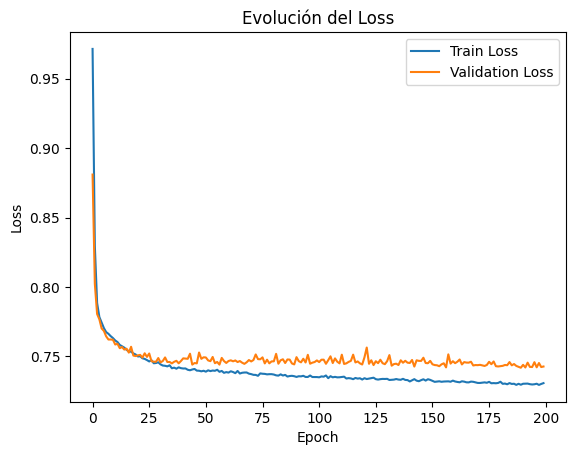

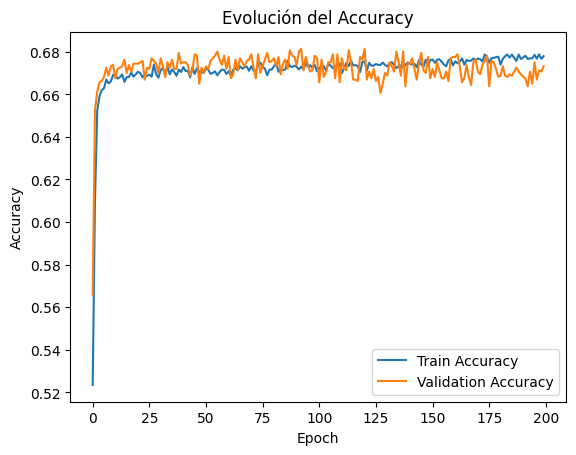

In [35]:
import matplotlib.pyplot as plt

# Graficar LOSS
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución del Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Graficar ACCURACY
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolución del Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [36]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss en test:", loss)
print("Accuracy en test:", accuracy)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6806 - loss: 0.7314
Loss en test: 0.7275456786155701
Accuracy en test: 0.6794666647911072


In [38]:
import numpy as np

# Predicciones del modelo
y_pred = model.predict(X_test)

# Convertir probabilidades a clases
y_pred_classes = np.argmax(y_pred, axis=1)

# Convertir y_test de one-hot a clases
y_test_classes = np.argmax(y_test, axis=1)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_classes, y_pred_classes)

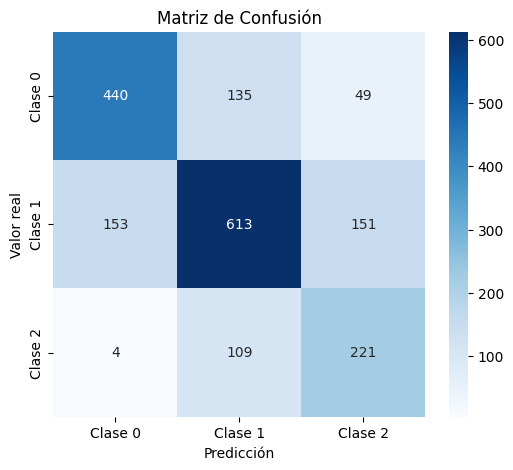

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Clase 0','Clase 1','Clase 2'],
    yticklabels=['Clase 0','Clase 1','Clase 2']
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")

plt.show()

In [41]:
model.save("modelo_red_neuronal.keras")